In [1]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist
import hist.dask as hda

import vector as vec

import numba

In [2]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }    

In [3]:
x_sections = {
                'QCD_PT-120to170': 445800.0,
                'QCD_PT-170to300': 113700.0,
                'QCD_PT-300to470': 7589.0,
                'QCD_PT-470to600': 626.4,
                'QCD_PT-600to800': 178.6,
                'QCD_PT-800to1000': 30.57,
                'QCD_PT-1000to1400': 8.92,
                'QCD_PT-1400to1800': 0.8103,
                'QCD_PT-1800to2400': 0.1148,
                'QCD_PT-2400to3200': 0.007542,
                'QCD_PT-3200': 0.0002331,
                'TTto4Q': 762.1
}


def sample_name(name):
    for key in x_sections.keys():
        if key in name:
            return key
    return None

In [4]:
def mass_asymmetry(sj, tj):
    total_p4 = sj[:,0] + sj[:,1] + sj[:,2] + sj[:,3] + sj[:,4] + sj[:,5]
    cart = ak.cartesian([total_p4, tj])
    vector = (cart['1'].j1 + cart['1'].j2 + cart['1'].j3)
    other_vector = (cart['0'] - vector)

    vm = vector.mass
    ovm =other_vector.mass
    masym = (vm - ovm)/(vm + ovm)
    return masym

def tri_mds(tj):
    den=((tj.j1+tj.j2+tj.j3).mass**2)+(tj.j1.mass**2)+(tj.j2.mass**2)+(tj.j3.mass**2)

    m12=((tj.j1+tj.j2).mass**2)/den
    m13=((tj.j1+tj.j3).mass**2)/den
    m23=((tj.j2+tj.j3).mass**2)/den
    #d=ak.zip({"1":m12, "2":m13,"3":m23})
    #d=ak.concatenate([m12[:, np.newaxis], m13[:, np.newaxis],m23[:, np.newaxis]],axis=1)

    r13 = 1/(3**0.5)
    mds=((m12**0.5)-r13)**2 + ((m13**0.5)-r13)**2 + ((m23**0.5)-r13)**2
    #tmds = mds,d[0],d[1],d[2]
    # print(tmds)
    # print(len(tmds))
    return mds, m12, m13, m23

def tri_delta(tj):
    return tj.j1.pt + tj.j2.pt + tj.j3.pt - (tj.j1 + tj.j2 + tj.j3).mass

def tri_mds63(sj, tj):
        total_p4 = sj[:,0] + sj[:,1] + sj[:,2] + sj[:,3] + sj[:,4] + sj[:,5]
        den = 4*total_p4.mass**2 + 6*(sj[:,0].mass**2 + sj[:,1].mass**2  + sj[:,2].mass**2  + sj[:,3].mass**2  + sj[:,4].mass**2  + sj[:,5].mass**2 ) 
        r120 = 1/(20**0.5)
        return ak.sum((((tj.j1 + tj.j2 + tj.j3).mass/den)-r120)**2, axis=1)

def tri_mds6332(sj, tj, mds):
        total_p4 = sj[:,0] + sj[:,1] + sj[:,2] + sj[:,3] + sj[:,4] + sj[:,5]
        den = 4*total_p4.mass**2 + 6*(sj[:,0].mass**2 + sj[:,1].mass**2  + sj[:,2].mass**2  + sj[:,3].mass**2  + sj[:,4].mass**2  + sj[:,5].mass**2 ) 
        r120 = 1/(20**0.5)
        return ak.sum(((((tj.j1 + tj.j2 + tj.j3).mass/den)**2 + mds**0.5)-r120)**2, axis=1)


In [5]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:3]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

qcd_events = {}

for f in [line.strip('\n') for line in open("Run3/qcd_files.txt").readlines()]:
    #file_list = [line.strip('\n') for line in open(f).readlines()]
    #file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]
    qcd_events[sample_name(f)] = NanoEventsFactory.from_root(
        {str("root://cmseos.fnal.gov///store/group/lpcmultijets//johnny/2022/mc/qcd/" + f): "Events"},
        schemaclass=ScoutingNanoAODSchema,
        steps_per_file = 2_000,
        metadata={"dataset": sample_name(f)},
        ).events()
    
    #num_events = ak.num(qcd_events[sample_name(f)],axis=0).compute()
    #qcd_events[sample_name(f)]["Weight"] = dak.Array(np.full(num_events,(x_sections[sample_name(f)] / num_events)))

weights = {}

for ky in x_sections.keys():
    if ky not in ['TTto4Q']:
        weights[ky] = (x_sections[ky] / (ak.num(qcd_events[ky], axis=0))).compute()
    else:
        weights[ky] = (x_sections[ky] / (ak.num(small_events, axis=0))).compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/factory.py:307: RuntimeWarning: You have set steps_per_file to 2000, this should only be used for a
                small number of inputs (e.g. for early-stage/exploratory analysis) si

KeyboardInterrupt: 

In [6]:
for kyy in list(x_sections.keys()):
    if kyy not in ['TTto4Q']:
        print(ak.num(qcd_events[kyy], axis=0).compute())

12476265
10851975
21252529
19921210
28011050
12153240
4328530
3647520
2453207
789885
21537


In [8]:
qcd_events["QCD_PT-1000to1400"][0:10].compute()

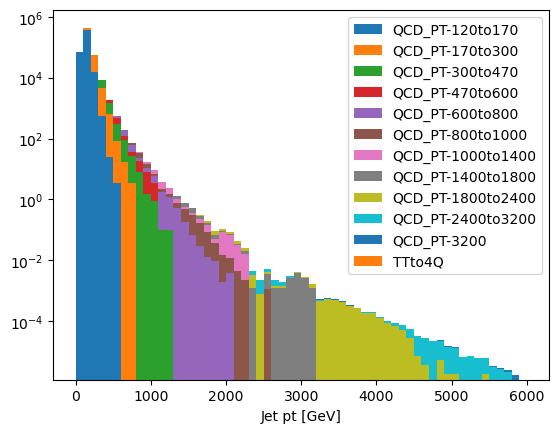

In [8]:
dask_hist =  (
    hda.Hist.new.Reg(60, 0, 6000, name="jet pt", label="Jet pt [GeV]")
    .StrCat(x_sections.keys(), name='dataset')
    .Weight()
)

for ky in x_sections.keys():
    if ky not in ['TTto4Q']:
        dask_hist.fill(ak.drop_none(ak.max(qcd_events[ky].ScoutingJet.pt,axis=1)), ky, weight=weights[ky])

dask_hist.compute().plot1d(stack=True,histtype="fill")
plt.yscale('log')
plt.legend()

In [77]:
vec.register_awkward()

def format_good_events(ev):
    sel = PackedSelection()
    sel.add("SixJets", ak.num(ev.ScoutingJet[ev.ScoutingJet.eta < 2.4], axis=1) >5)

    result = ev[sel.all("SixJets")]
    selected_jets = result.ScoutingJet[result.ScoutingJet.eta < 2.4][:,0:6]
    trijet = ak.combinations(selected_jets, 3, fields=["j1","j2","j3"])

    mds_val, m12, m13, m23 = tri_mds(trijet)

    result["Trijet"] = ak.zip(
        {
            "j1": trijet.j1,
            "j2": trijet.j2,
            "j3": trijet.j3,
            "px": trijet.j1.px + trijet.j2.px + trijet.j3.px, 
            "py": trijet.j1.py + trijet.j2.py + trijet.j3.py, 
            "pz": trijet.j1.pz + trijet.j2.pz + trijet.j3.pz,
            "e": trijet.j1.E + trijet.j2.E + trijet.j3.E,
            "masym": mass_asymmetry(selected_jets,trijet),
            "mds": mds_val,
            "m12": m12,
            "m13": m13,
            "m23": m23,
            "delta": tri_delta(trijet),
            "mds63": tri_mds63(selected_jets, trijet)
            
        },
        with_name="Momentum4D"
    )

    result["HT"] = ak.sum(abs(result.ScoutingJet.pt), axis=1)
    result["mds6332"] = tri_mds6332(selected_jets, trijet, mds_val)

    return result

In [78]:
good_qcd_events = {}

for key in x_sections.keys():
    if key not in ['TTto4Q']:
        good_qcd_events[key] = format_good_events(qcd_events[key])

good_events = format_good_events(small_events)

In [15]:
h1 = Hist(
    hist.axis.Regular(50, 0, 3000, name="x", label="HT"),
    hist.storage.Weight()
)
h1.fill(good_events.HT.compute())

Hist(Regular(50, 0, 3000, name='x', label='HT'), storage=Weight()) # Sum: WeightedSum(value=90743, variance=90743) (WeightedSum(value=90748, variance=90748) with flow)

In [36]:
dask_hist_HT =  (
    hda.Hist.new.Reg(60, 0, 6000, name="ht", label="HT [GeV]")
    .StrCat([i for i in x_sections.keys() if i not in ['TTto4Q']], name='dataset')
    .Weight()
)

for ky in x_sections.keys():
    if ky not in ['TTto4Q']:
        dask_hist_HT.fill(good_qcd_events[ky].HT, ky, weight=weights[ky])


dask_hist_HT_tt =  (
    hda.Hist.new.Reg(60, 0, 6000, name="ht", label="HT [GeV]")
    .Weight()
)
dask_hist_HT_tt.fill(good_events.HT, weight=weights['TTto4Q'])

hq = dask_hist_HT.compute()
ht = dask_hist_HT_tt.compute()

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: invalid value encountered in divide
  counts = sumw / scale
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: invalid value encountered in divide
  counts = sumw / scale
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarning: divide by zero encountered in divide
  counts = sumw / scale
/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/mplhep/error_estimation.py:49: RuntimeWarn

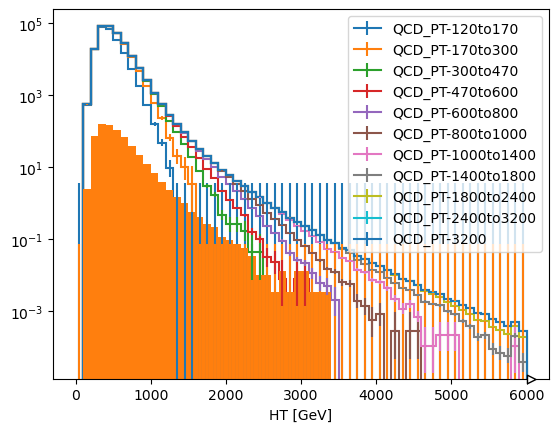

In [37]:
hq.plot1d(stack=True,histtype="step")
ht.plot1d(stack=False,histtype="fill")
plt.yscale("log")
plt.legend()

In [169]:
h2 = Hist(
    hist.axis.Regular(50, 0, 3600, name="x", label="Jet Pt"),
    hist.storage.Weight()
)
h2.fill(ak.flatten(good_events.ScoutingJet.pt).compute())

Hist(Regular(50, 0, 3600, name='x', label='Jet Pt'), storage=Weight()) # Sum: WeightedSum(value=930810, variance=930810)

In [72]:
h4 = Hist(
    hist.axis.Regular(50, 100, 300, name="x", label="Trijet Invariant Mass"),
    hist.axis.StrCategory(['Full'], growth=True, name='dataset'),
    hist.storage.Weight()
)
h4.fill(ak.flatten(good_events.Trijet.mass.compute()), "Full")
overallcut = (good_events.HT > 550)
cut_events = good_events[overallcut]
cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) #& (cut_events.Trijet.delta > 250)
h4.fill(ak.flatten(cut_events.Trijet[cut].mass.compute()), "CutNoDelta")
cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 0)
h4.fill(ak.flatten(cut_events.Trijet[cut].mass.compute()), "DeltaGr0")
cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 125)
h4.fill(ak.flatten(cut_events.Trijet[cut].mass.compute()), "DeltaGr125")
cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 250)
h4.fill(ak.flatten(cut_events.Trijet[cut].mass.compute()), "DeltaGr250")
cut_events = good_events #[overallcut]
cut = ak.argmin(cut_events.Trijet.masym,axis=1,keepdims=True)
h4.fill(ak.flatten(cut_events.Trijet[cut].mass).compute(), "MinAsy")


Hist(
  Regular(50, 100, 300, name='x', label='Trijet Invariant Mass'),
  StrCategory(['Full', 'CutNoDelta', 'DeltaGr0', 'DeltaGr125', 'DeltaGr250', 'MinAsy'], growth=True, name='dataset'),
  storage=Weight()) # Sum: WeightedSum(value=3.06904e+06, variance=3.06904e+06) (WeightedSum(value=4.48079e+06, variance=4.48079e+06) with flow)

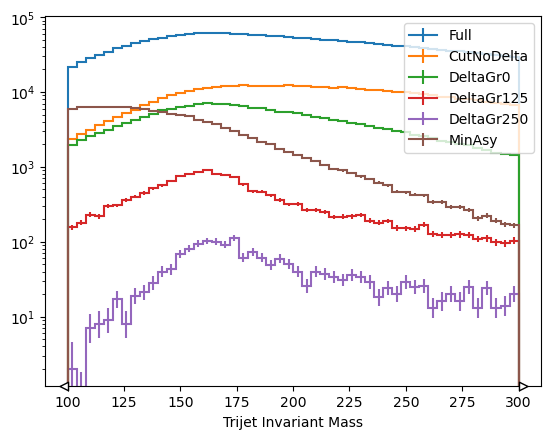

In [73]:
h4.plot(stack=False, histtype="step")
plt.yscale("log")
plt.legend(loc="upper right")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


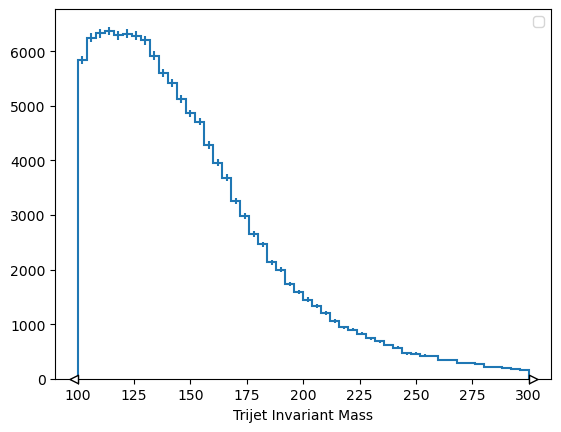

In [74]:
h4[:,"MinAsy"].plot(stack=False, histtype="step")
plt.legend(loc="upper right")

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/hist/basehist.py:406: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


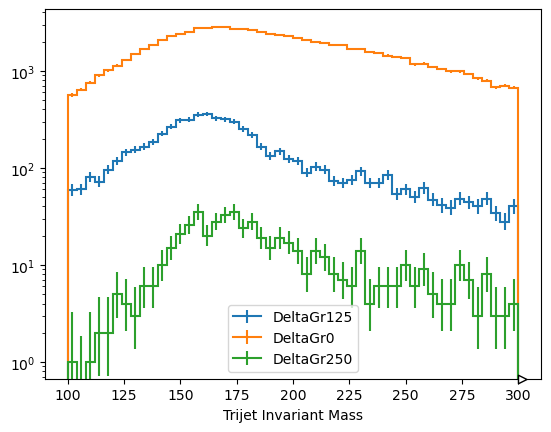

In [76]:
h4[:,["DeltaGr125","DeltaGr0","DeltaGr250"]].plot(stack=False, histtype="step")
plt.yscale("log")
plt.legend()

In [ ]:
h4 = Hist(
    hist.axis.Regular(50, 100, 300, name="x", label="Trijet Invariant Mass"),
    hist.axis.StrCategory(['Full', 'Cut'], growth=True, name='dataset'),
    hist.storage.Weight()
)
h4.fill(ak.flatten(good_events.Trijet.mass.compute()), "Full")
overallcut = (good_events.mds6332 < 1.25)
cut_events = good_events[overallcut]
cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 250)

In [79]:
def fill_cut_hist(tmp_hist, ev, label):
    overallcut = (ev.HT > 550)
    cut_events = ev[overallcut]
    cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) & (cut_events.Trijet.delta > 250)
    tmp_hist.fill(ak.flatten(cut_events.Trijet[cut].mass), "Cut", weight=weights[label])

dask_hist_mass =  (
    hda.Hist.new.Reg(60, 100, 300, name="mass_qcd", label="Inv Mass [GeV]")
    .StrCat(["Full","Cut"], name='dataset')
    .Weight()
)

for ky in x_sections.keys():
    if ky not in ['TTto4Q']:
        dask_hist_mass.fill(ak.flatten(good_qcd_events[ky].Trijet.mass), "Full", weight=weights[ky])
        fill_cut_hist(dask_hist_mass, good_qcd_events[ky], ky)
        # overallcut = (ev.HT > 550)
        # cut_events = ev #[overallcut]
        # cut = (cut_events.Trijet.masym < 0.15) & (cut_events.Trijet.mds < 0.175) #& (cut_events.Trijet.delta > 250)
        # tmp_hist.fill(ak.flatten(cut_events.Trijet.mass), "Cut", weight=weights[label])


dask_hist_mass_tt =  (
    hda.Hist.new.Reg(60, 100, 300, name="mass_tt", label="Inv Mass [GeV]")
    .StrCat(["Full","Cut"], name='dataset')
    .Weight()
)
dask_hist_mass_tt.fill(ak.flatten(good_events.Trijet.mass), "Full", weight=weights['TTto4Q'])
fill_cut_hist(dask_hist_mass_tt, good_events, 'TTto4Q')

hqm = dask_hist_mass.compute()
htm = dask_hist_mass_tt.compute()

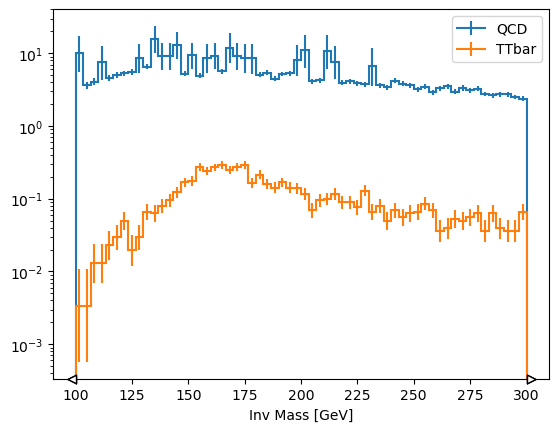

In [76]:
hqm[:,'Cut'].plot1d(stack=True,label="QCD")
htm[:,'Cut'].plot1d(stack=True,label="TTbar")


plt.yscale('log')
plt.legend()

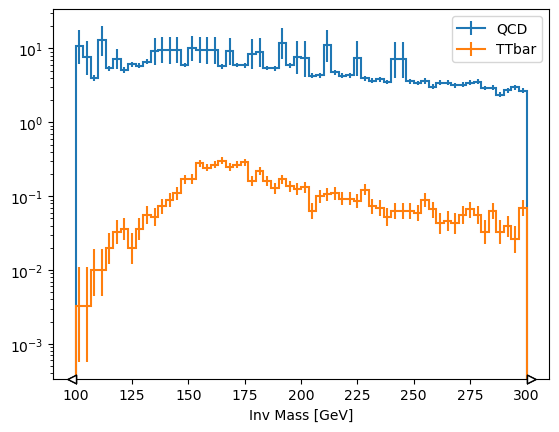

In [80]:
hqm[:,'Cut'].plot1d(stack=True,label="QCD")
htm[:,'Cut'].plot1d(stack=True,label="TTbar")


plt.yscale('log')
plt.legend()